In [1]:
print("Start")

Start


In [112]:
import copy
import numpy as np 

import torch
import torch.optim as optim 
import torch.nn as nn 
import torch.nn.functional as F 

import torchvision
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset,Subset
from torchvision import transforms
from torchvision.transforms import Compose, Normalize, Pad
from torchvision import models

import cv2
from PIL import Image
import pandas as pd

import matplotlib.pyplot as plt
from torchvision.ops import nms

from PIL import Image, ImageDraw, ImageFont

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Applying `local_binary_pattern` to floating-point images"
)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
%pip install selectivesearch

  Preparing metadata (setup.py) ... done
  Created wheel for selectivesearch: filename=selectivesearch-0.4-py3-none-any.whl size=4372 sha256=4531b09e0ffb715f18244e9ef6353b18899f7fe4fae25253e2fcf06108c238a4
  Stored in directory: /root/.cache/pip/wheels/7f/9b/c7/58b71f1e9fe4aa0ef8affd1c673f8818bc22a5091ea8cbbe93
Successfully built selectivesearch
Note: you may need to restart the kernel to use updated packages.


In [6]:
import selectivesearch

In [7]:
Image_root = "/kaggle/input/datasets/sixhky/open-images-bus-trucks/images/images"

In [8]:
df_raw = pd.read_csv("/kaggle/input/datasets/sixhky/open-images-bus-trucks/df.csv")

In [9]:
df_raw.head()

,ImageID,Source,LabelName,Confidence,XMin,XMax,YMin,YMax,IsOccluded,IsTruncated,...,IsDepiction,IsInside,XClick1X,XClick2X,XClick3X,XClick4X,XClick1Y,XClick2Y,XClick3Y,XClick4Y
0,0000599864fd15b3,xclick,Bus,1,0.343750,0.908750,0.156162,0.650047,1,0,...,0,0,0.421875,0.343750,0.795000,0.908750,0.156162,0.512700,0.650047,0.457197
1,00006bdb1eb5cd74,xclick,Truck,1,0.276667,0.697500,0.141604,0.437343,1,0,...,0,0,0.299167,0.276667,0.697500,0.659167,0.141604,0.241855,0.352130,0.437343
2,00006bdb1eb5cd74,xclick,Truck,1,0.702500,0.999167,0.204261,0.409774,1,1,...,0,0,0.849167,0.702500,0.906667,0.999167,0.204261,0.398496,0.409774,0.295739
3,00010bf498b64bab,xclick,Bus,1,0.156250,0.371250,0.269188,0.705228,0,0,...,0,0,0.274375,0.371250,0.311875,0.156250,0.269188,0.493882,0.705228,0.521691
4,00013f14dd4e168f,xclick,Bus,1,0.287500,0.999375,0.194184,0.999062,0,1,...,0,0,0.920000,0.999375,0.648750,0.287500,0.194184,0.303940,0.999062,0.523452


In [10]:
class OpenImages(Dataset):
    def __init__(self,df,image_folder=Image_root):
        self.root = image_folder
        self.df = df
        self.unique_images = df["ImageID"].unique()
    def __len__(self):
        return len(self.unique_images)
    def __getitem__(self,ix):
        image_id = self.unique_images[ix]
        image_path = f"{self.root}/{image_id}.jpg"
        image = cv2.imread(image_path,1)[...,::-1]
        h,w, _ = image.shape
        df = self.df.copy()
        df = df[df["ImageID"] == image_id]
        boxes = df["XMin,YMin,XMax,YMax".split(",")].values
        boxes = (boxes*np.array([w,h,w,h])).astype(np.uint16).tolist()
        classes = df["LabelName"].values.tolist()
        return image, boxes, classes, image_path

In [11]:
ds = OpenImages(df=df_raw)

In [12]:
def get_candidates(img):
    img_lbl, regions = selectivesearch.selective_search(img,scale=200,min_size=100)
    img_area = np.prod(img.shape[:2])
    candidates = []
    for r in regions:
        if r["rect"] in candidates:
            continue
        if r["size"] < (0.05*img_area):
            continue
        if r["size"] > (1*img_area):
            continue
        x, y, w, h = r["rect"]
        candidates.append(list(r["rect"]))
    return candidates
def get_iou(boxA,boxB,epsilon=1e-5):
    x1 = max(boxA[0],boxB[0])
    y1 = max(boxA[1],boxB[1])
    x2 = min(boxA[2],boxB[2])
    y2 = min(boxA[3],boxB[3])
    width = (x2-x1)
    height = (y2-y1)
    if (width<0) or (height<0):
        return 0.0
    area_overlap = width * height
    area_a = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    area_b = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    area_combined = area_a + area_b - area_overlap
    iou = area_overlap/(area_combined+epsilon)
    return iou

In [13]:
FPATHS, GTBBS, CLSS, DELTAS, ROIS, IOUS = [],[],[],[],[],[]

In [14]:
N = 500
for ix, (im,bbs,labels,fpath) in enumerate(ds):
    if ix == N:
        break
    H,W, _ = im.shape
    candidates = get_candidates(im)
    all_candidates = []
    for i in range(0,len(candidates)):
        x,y,w,h  = candidates[i]
        all_candidates.append([x,y,x+w,y+h])
    all_candidates = np.array(all_candidates)
    ious, rois, clss, deltas = [], [], [], []
    
    for v in range(0,len(bbs)):
        temp = []
        for v1 in range(0,len(all_candidates)):
            temp.append(get_iou(all_candidates[v1],bbs[v]))
        ious.append(temp)
    ious = np.array(ious)
    ious = ious.T
    for ix,can in enumerate(all_candidates):
        cx,cy,cX,cY = can 
        corresponding_ious = ious[ix]
        max_iou_index = np.argmax(corresponding_ious)
        max_iou = corresponding_ious[max_iou_index]
        corresponding_max_iou_bbox = bbs[max_iou_index]
        _x,_y,_X,_Y = corresponding_max_iou_bbox
        if max_iou > 0.3:
            clss.append(labels[max_iou_index])
        else:
            clss.append("background")
        delta = np.array([
            _x-cx,
            _y-cy,
            _X-cX,
            _Y-cY
        ])/np.array([W,H,W,H])
        deltas.append(delta)
        can = can/np.array([W,H,W,H])
        rois.append(can)
    FPATHS.append(fpath)
    IOUS.append(ious)
    ROIS.append(rois)
    CLSS.append(clss)
    DELTAS.append(deltas)
        

In [15]:
# FPATHS[i] has the image path of the ith image
# IOUS[i] has the ious between all the candidates and the bbs for the ith image
# ROIS[i] has all the candidates from selective search for the ith image
# CLSS[i] has all the labels for all the rois in ROIS[i]
# DELTAS[i] has the normalized difference between each roi and its corresponding max iou bbs

In [16]:
unique_labels = set()
for fire in CLSS:
    for ice in fire:
        unique_labels.add(ice)
print(unique_labels)

{'Truck', 'background', 'Bus'}


In [17]:
label2target = {"Bus":1,"background":0,"Truck":2}
target2label = {1:"Bus",0:"background",2:"Truck"}

In [18]:
normalize = transforms.Normalize(mean=[0.485,0.456,0.406],
                                std=[0.229,0.224,0.225])

In [19]:
def preprocess_image(img):
    img = torch.tensor(img).permute(2,0,1)
    img = normalize(img)
    return img.to(device).float()

In [20]:
def decode(_y):
    _, preds = _y.max(-1)
    return preds 

In [21]:
class RCNN_Dataset(Dataset):
    def __init__(self,fpaths,rois,labels,deltas):
        self.fpaths = fpaths
        self.rois = rois
        self.labels = labels
        self.deltas = deltas 
    def __len__(self):
        return len(self.fpaths)
    def __getitem__(self,index):
        fpath = self.fpaths[index]
        img = cv2.imread(fpath,1)[...,::-1]
        H,W,_ = img.shape
        scale = np.array([W,H,W,H])
        rois = self.rois[index].copy()
        rois = (np.array(rois)*scale).astype(np.uint16)
        labels = self.labels[index].copy()
        deltas = self.deltas[index].copy()
        crops = [img[y:Y,x:X] for (x,y,X,Y) in rois]
        for i in range(0,len(crops)):
            crops[i] = cv2.resize(crops[i],(224,224))
            crops[i] = preprocess_image(crops[i]/255.)[None]
        for i in range(0,len(labels)):
            labels[i] = label2target[labels[i]]
        labels = torch.tensor(labels).long().to(device)
        deltas = np.array(deltas)
        deltas = torch.tensor(deltas).float().to(device)
        return crops, labels, deltas,fpath 
    def collate_fn(self,batch):
        batch_images, batch_labels, batch_deltas = [], [], []
        for i in range(len(batch)):
            crops, labels, deltas,fpath  = batch[i]
            for j in range(0,len(crops)):
                batch_images.append(crops[j])
            for j in range(0,labels.shape[0]):
                batch_labels.append(labels[j])
            for j in range(0,deltas.shape[0]):
                batch_deltas.append(deltas[j])
        batch_images = torch.cat(batch_images,dim=0)
        batch_labels = torch.stack(batch_labels)
        batch_deltas = torch.stack(batch_deltas)
        return batch_images,batch_labels,batch_deltas
                

In [22]:
rcnn_ds = RCNN_Dataset(FPATHS, ROIS, CLSS, DELTAS)

In [23]:
def index_splitter(number,amount):
    indices = np.arange(number)
    amount = torch.tensor(amount)
    amount = amount * number
    amount = amount / 100
    amount = amount.int()
    amount[0] += (number-amount.sum())
    split1, split2,split3 = random_split(indices,amount)
    return split1.indices,split2.indices,split3.indices

In [24]:
train_indices,test_indices,val_indices = index_splitter(len(rcnn_ds),[90,5,5])

In [25]:
train_set = Subset(rcnn_ds,train_indices)
test_set = Subset(rcnn_ds,test_indices)
val_set = Subset(rcnn_ds,val_indices)

In [26]:
val_set[1][3]

'/kaggle/input/datasets/sixhky/open-images-bus-trucks/images/images/000e83dc68db5ca8.jpg'

In [27]:
print(len(train_indices))
print(len(test_indices))
print(len(val_indices))
print(len(FPATHS))

450
25
25
500


In [28]:
train_loader = DataLoader(train_set,batch_size=2,collate_fn=rcnn_ds.collate_fn)
#test_loader = DataLoader(test_set,batch_size=2,collate_fn=rcnn_ds.collate_fn)
val_loader = DataLoader(val_set,batch_size=2,collate_fn=rcnn_ds.collate_fn)

In [29]:
#dl_mine = DataLoader(rcnn_ds, batch_size=32,collate_fn=rcnn_ds.collate_fn)

In [30]:
for x1,x2,x3 in train_loader:
    print(x1.shape)
    print(type(x1[0]))
    print(x2.shape)
    print(type(x2[0]))
    print(x3.shape)
    print(type(x3[0]))
    break

torch.Size([51, 3, 224, 224])
<class 'torch.Tensor'>
torch.Size([51])
<class 'torch.Tensor'>
torch.Size([51, 4])
<class 'torch.Tensor'>


In [31]:
print(len(train_loader))

225


In [32]:
vgg_backbone = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 219MB/s] 


In [33]:
vgg_backbone

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [34]:
vgg_backbone.classifier = nn.Identity()

In [35]:
for param in vgg_backbone.parameters():
    param.requires_grad = False

In [36]:
#vgg_backbone.eval().to(device)

In [37]:
dummy_pic =torch.randn(1,3,224,224).to(device)

In [38]:
vgg_backbone = vgg_backbone.to(device)

In [39]:
dummy_feat = vgg_backbone(dummy_pic)

In [40]:
dummy_feat.shape

torch.Size([1, 25088])

In [41]:
background_class = label2target["background"]

In [117]:
class RCNN_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = vgg_backbone
        self.cls_score = nn.Linear(dummy_feat.shape[1],len(label2target))
        self.bounding_box = nn.Sequential(
            nn.Linear(dummy_feat.shape[1],512),
            nn.Dropout(0.3),
            nn.ReLU(),
            nn.Linear(512,4),
            nn.Tanh()
        )
    def forward(self,x):
        features = self.backbone(x)
        cls_logit = self.cls_score(features)
        pred_delta = self.bounding_box(features)
        return cls_logit, pred_delta

In [118]:
def RCNN_loss(predicted_cls_logit,cls,predicted_deltas,deltas):
    classification_loss = nn.CrossEntropyLoss()(predicted_cls_logit,cls)
    indices = []
    for i in range(0,len(cls)):
        if cls[i]!=0:
            indices.append(i)
    predicted_deltas = predicted_deltas[indices]
    deltas = deltas[indices]
    if len(indices)!=0:
        regression_loss = nn.L1Loss()(predicted_deltas,deltas)
    else:
        regression_loss = predicted_deltas.sum() * 0.0

    total_loss = classification_loss + 10.0 * regression_loss
    return total_loss, classification_loss.detach(), regression_loss.detach()

In [119]:
model = RCNN_model().to(device)
loss_fn = RCNN_loss

In [120]:
for x1,x2,x3 in train_loader:
    x1 = x1.to(device)
    x2 = x2.to(device)
    x3 = x3.to(device)
    cls_logit, predicted_bbox = model(x1)
    total_loss, cls_loss, regr_loss = loss_fn(cls_logit,x2,predicted_bbox,x3)
    print(total_loss.item())
    break

4.321181297302246


In [121]:
class DeepLearner:
    def __init__(self,model,loss_fn,optimizer):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.best_val_loss = float("inf")
        self.best_model_weights = None
        self.best_optimizer_state = None
        self.last_model_weights = None
        self.last_optimizer_state = None
        self.train_losses = []
        self.val_losses = []
        self.epoch = 0 
        self.train_loader = None
        self.val_loader = None
        self.test_loader = None
    def set_loaders(self,train_loader=None,val_loader=None,test_loader=None):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
    def train_each_batch(self):
        train_loss = 0.0
        self.model.train()
        for img,lbl,dlt in self.train_loader:
            img = img.to(self.device)
            lbl = lbl.to(self.device)
            dlt = dlt.to(self.device)
            self.optimizer.zero_grad()
            cls_logit, predicted_bbox = self.model(img)
            total_loss, cls_loss, regr_loss = self.loss_fn(cls_logit,lbl,predicted_bbox,dlt)
            train_loss += total_loss.item()
            total_loss.backward()
            self.optimizer.step()
        train_loss = train_loss/len(self.train_loader)
        return train_loss
    def evaluate_each_batch(self,val=True):
        if val:
            loader = self.val_loader
        else:
            loader = self.test_loader
        loss = 0.0
        self.model.eval()
        for img, lbl, dlt in loader:
            img = img.to(self.device)
            lbl = lbl.to(self.device)
            dlt = dlt.to(self.device)
            cls_logit, predicted_bbox = self.model(img)
            total_loss, cls_loss, regr_loss = self.loss_fn(cls_logit,lbl,predicted_bbox,dlt)
            loss += total_loss.item()
        loss = loss/len(loader)
        return loss
    def pick_the_best_model(self):
        self.last_model_weights = copy.deepcopy(self.model.state_dict())
        self.model.load_state_dict(self.best_model_weights)
    def plot(self):
        epochs = range(1, len(self.train_losses) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_losses, marker="o", label="Training Loss")
        plt.plot(epochs, self.val_losses, marker="o", label="Validation Loss")


        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.xticks(epochs)
        plt.legend()
        plt.grid(True)

        plt.show()
    def train(self,n_epoch):
        if self.epoch != 0:
            self.model.load_state_dict(self.last_model_weights)
            self.optimizer.load_state_dict(self.last_optimizer_state)
        initial_epoch = self.epoch
        while self.epoch + 1 <= initial_epoch + n_epoch:
            self.epoch += 1 
            train_loss = self.train_each_batch()
            self.train_losses.append(train_loss)
            val_loss = self.evaluate_each_batch()
            self.val_losses.append(val_loss)
            print("Epoch:",self.epoch)
            print("Training Loss:",train_loss)
            print("Validatin Loss:",val_loss)
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss 
                self.best_model_weights = copy.deepcopy(self.model.state_dict())
                self.best_optimizer_state = copy.deepcopy(self.optimizer.state_dict())
                print("✅Best Model saved from epoch",self.epoch,"with validation loss",val_loss)
        self.last_model_weights = copy.deepcopy(self.model.state_dict())
        self.last_optimizer_state = copy.deepcopy(self.optimizer.state_dict())
        self.plot()

In [122]:
rcnn_model = RCNN_model()
rcnn_loss_fn = RCNN_loss
optimizer = optim.SGD(rcnn_model.parameters(),lr=1e-3)

In [123]:
dl1 = DeepLearner(rcnn_model, rcnn_loss_fn,optimizer)
dl1.set_loaders(train_loader,val_loader)

In [124]:
dl = DeepLearner(rcnn_model, rcnn_loss_fn,optimizer)
dl.set_loaders(train_loader,val_loader)

Epoch: 1
Training Loss: 1.9385501784086228
Validatin Loss: 1.426488344485943
✅Best Model saved from epoch 1 with validation loss 1.426488344485943
Epoch: 2
Training Loss: 1.206860338581933
Validatin Loss: 1.3472020855316749
✅Best Model saved from epoch 2 with validation loss 1.3472020855316749
Epoch: 3
Training Loss: 0.9354626152912776
Validatin Loss: 1.3132430865214422
✅Best Model saved from epoch 3 with validation loss 1.3132430865214422
Epoch: 4
Training Loss: 0.805619177536832
Validatin Loss: 1.3197812667259803
Epoch: 5
Training Loss: 0.7186762469510237
Validatin Loss: 1.320930568071512
Epoch: 6
Training Loss: 0.6630709250768025
Validatin Loss: 1.292370278101701
✅Best Model saved from epoch 6 with validation loss 1.292370278101701
Epoch: 7
Training Loss: 0.6178902365598413
Validatin Loss: 1.3055186730164747


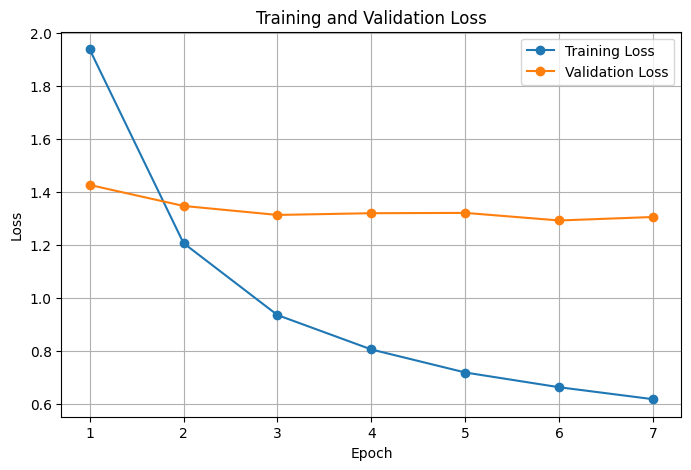

In [125]:
dl.train(7)

In [132]:
def evaluate_on_unseen_image(image_path, confidence_threshold = 0.5, nms_threshold=0.3):
    img = cv2.imread(image_path,1)[...,::-1]
    H,W,_ = img.shape
    candidates = get_candidates(img)
    all_candidates = []
    for i in range(0,len(candidates)):
        x,y,w,h = candidates[i]
        all_candidates.append([x,y,x+w,y+h])
    crops = []
    for i in range(0,len(all_candidates)):
        x,y,X,Y = all_candidates[i]
        cropped = img[y:Y,x:X]
        if cropped.shape[0] == 0 or cropped.shape[1] == 0:
            continue
        cropped = cv2.resize(cropped,(224,224))
        cropped = preprocess_image(cropped/255.0)
        cropped = cropped.unsqueeze(0)
        crops.append(cropped)
    if len(crops) == 0:
        print("No valid candidate found")
        return
    crops = torch.cat(crops,dim=0).to(device)
    dl.pick_the_best_model()
    dl.model.eval()
    with torch.no_grad():
        cls_logits, pred_deltas = dl.model(crops)
    probabilities = F.softmax(cls_logits,dim=1)

    confidence, predicted_classes = torch.max(probabilities,dim=1)

    confidence = confidence.cpu().numpy()
    predicted_classes = predicted_classes.cpu().numpy()
    pred_deltas = pred_deltas.cpu().numpy()

    all_candidates = np.array(all_candidates,dtype=np.float32)

    scale = np.array([W,H,W,H],dtype=np.float32)

    scaled_delta = pred_deltas * scale 
    predicted_boxes = all_candidates + scaled_delta 

    predicted_boxes[:, 0] = np.clip(predicted_boxes[:, 0], 0, W - 1)
    predicted_boxes[:, 1] = np.clip(predicted_boxes[:, 1], 0, H - 1)
    predicted_boxes[:, 2] = np.clip(predicted_boxes[:, 2], 0, W - 1)
    predicted_boxes[:, 3] = np.clip(predicted_boxes[:, 3], 0, H - 1)

    keep = predicted_classes != label2target["background"]

    confidence = confidence[keep]
    predicted_classes = predicted_classes[keep]
    predicted_boxes = predicted_boxes[keep]

    if len(predicted_boxes) == 0:
        print("No object detected")
        return

    keep = confidence >= confidence_threshold

    confidence = confidence[keep]
    predicted_classes = predicted_classes[keep]
    predicted_boxes = predicted_boxes[keep]

    if len(predicted_boxes)==0:
        print("No object detected")
        return

    nms_boxes = []
    for i in range(0,len(predicted_boxes)):
        x,y,X,Y = predicted_boxes[i]
        nms_boxes.append([float(x),float(y),float(X),float(Y)])
    nms_score = torch.tensor(confidence)
    nms_boxes = torch.tensor(nms_boxes)



    
    nms_indices = torchvision.ops.nms(
        nms_boxes,nms_score,nms_threshold
    )
    nms_indices = nms_indices.numpy()

    predicted_classes = predicted_classes[nms_indices]
    predicted_boxes = predicted_boxes[nms_indices]
    confidence = confidence[nms_indices]

    if len(predicted_boxes) == 0:
        print("NO OBJECT DETECTED")
        return


    display_img = img.copy()

    display_img_pil = Image.fromarray(display_img)

    draw = ImageDraw.Draw(display_img_pil)
    font = ImageFont.load_default()
    
    for box,score,cls in zip(predicted_boxes,confidence,predicted_classes):
        x1,y1,x2,y2 = box.astype(int)
        class_label = target2label[int(cls)]

        draw.rectangle(
        (x1, y1, x2, y2),
        outline=(0, 255, 0),
        width=2
        )

        scr = round(score,3)
        text = class_label +" : " + str(scr)

        text_x = x1
        text_y = max(y1 - 18, 0)

        draw.text(
        (text_x, text_y),
        text,
        font=font,
        fill=(0, 0, 255)
        )

    display_img = np.array(display_img_pil)
    plt.figure(figsize=(12, 8))
    plt.imshow(display_img)
    plt.axis("off")
    plt.show()
    #test it mine

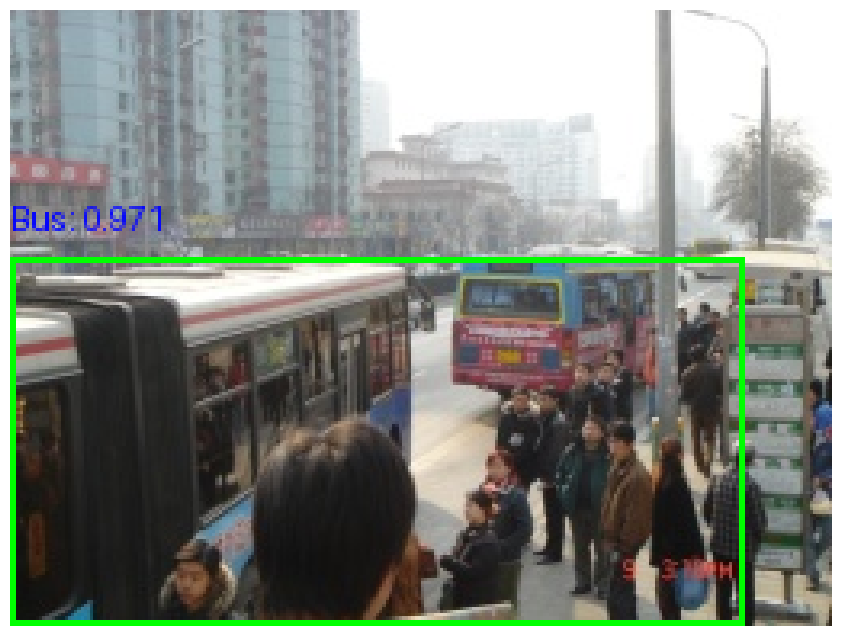

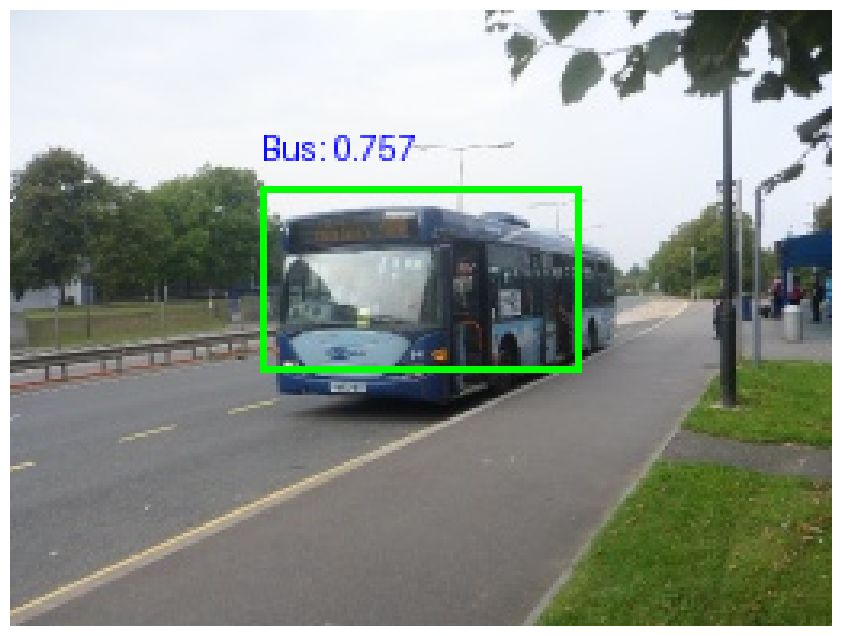

No object detected


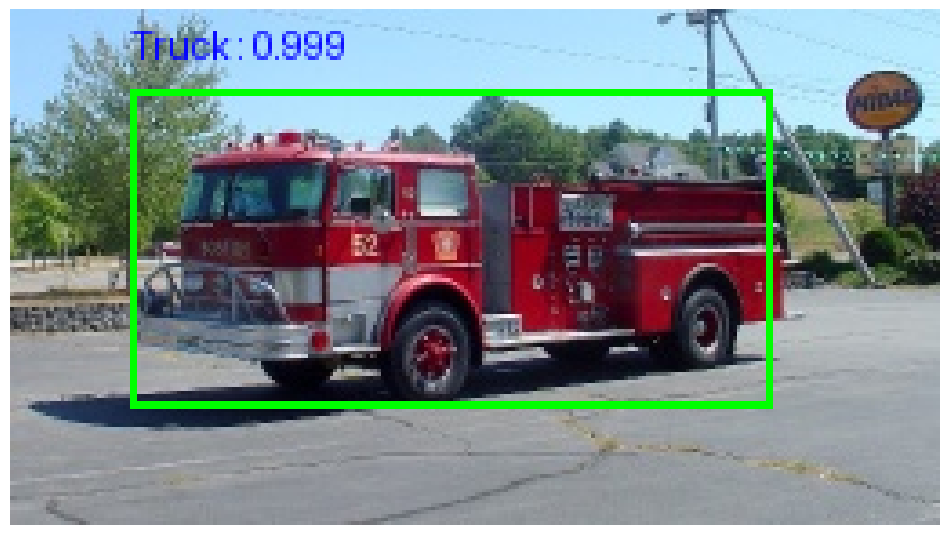

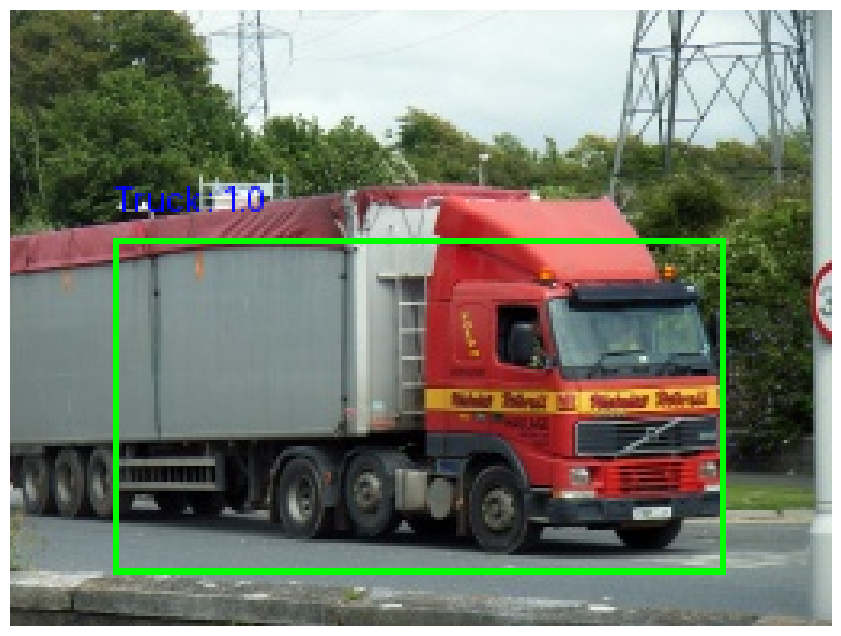

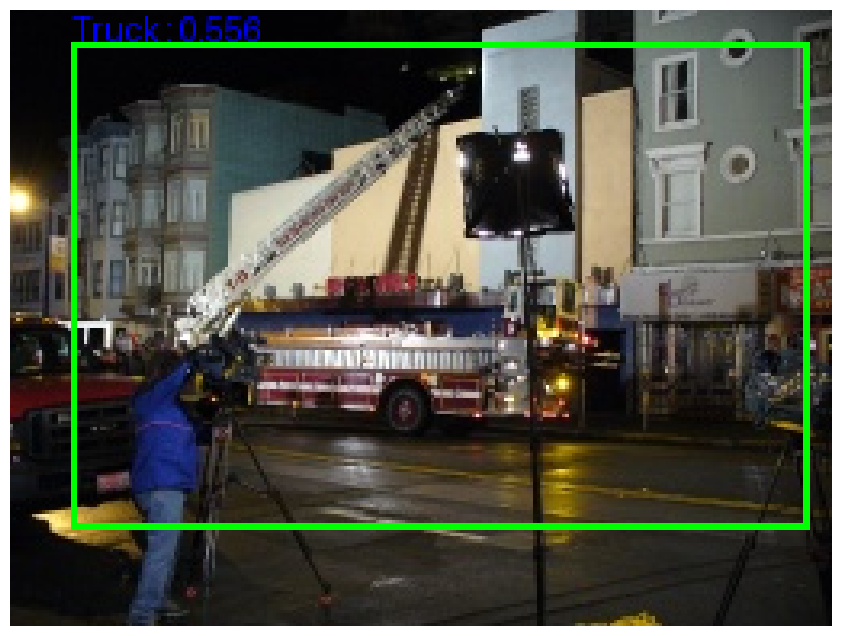

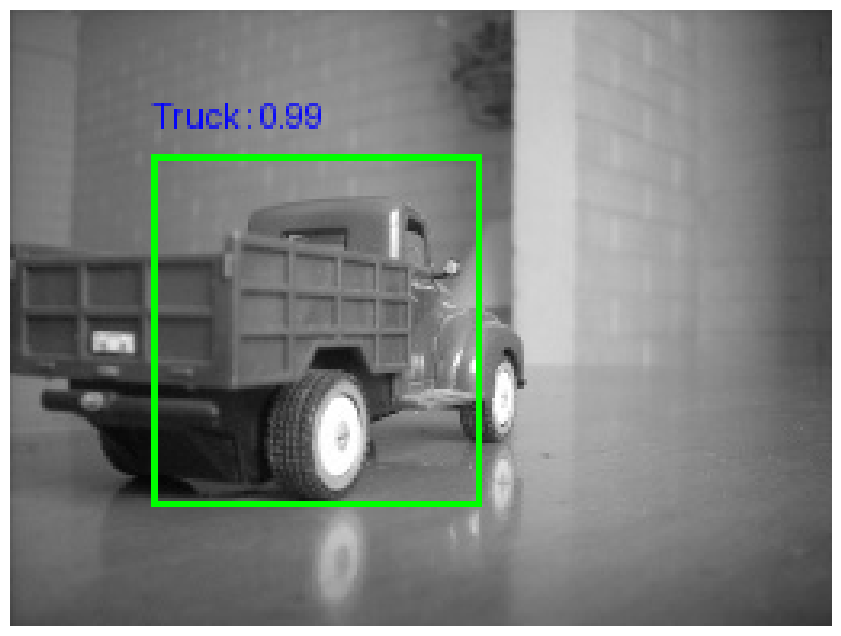

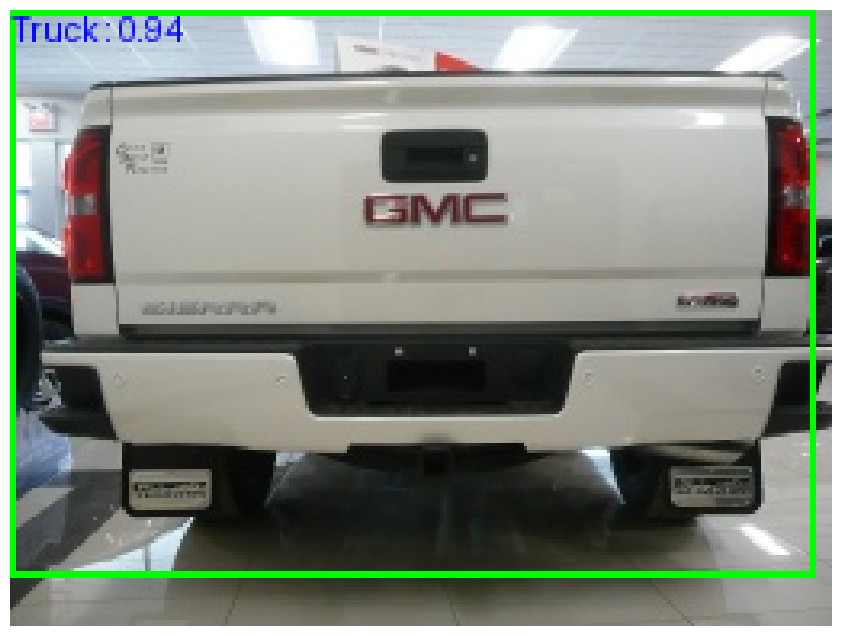

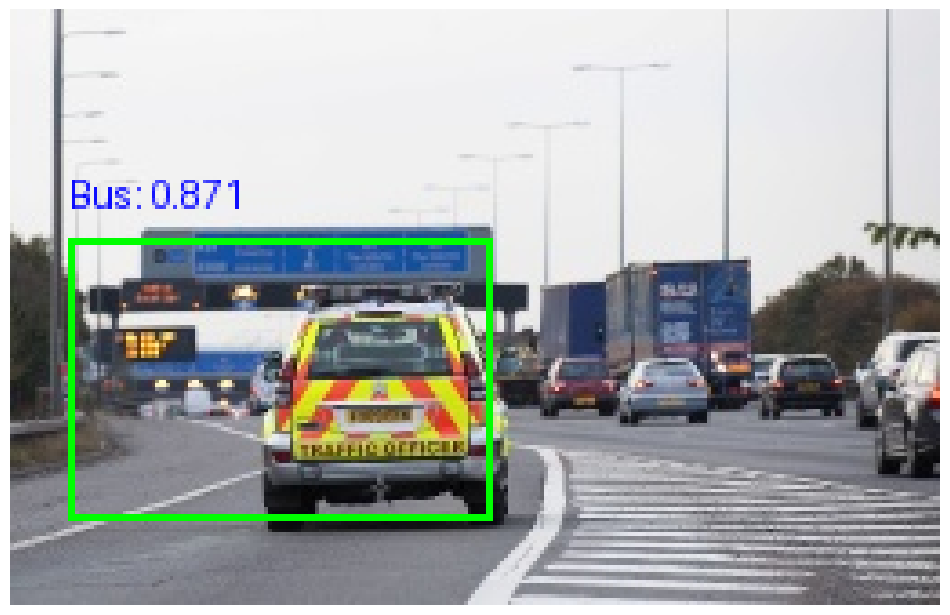

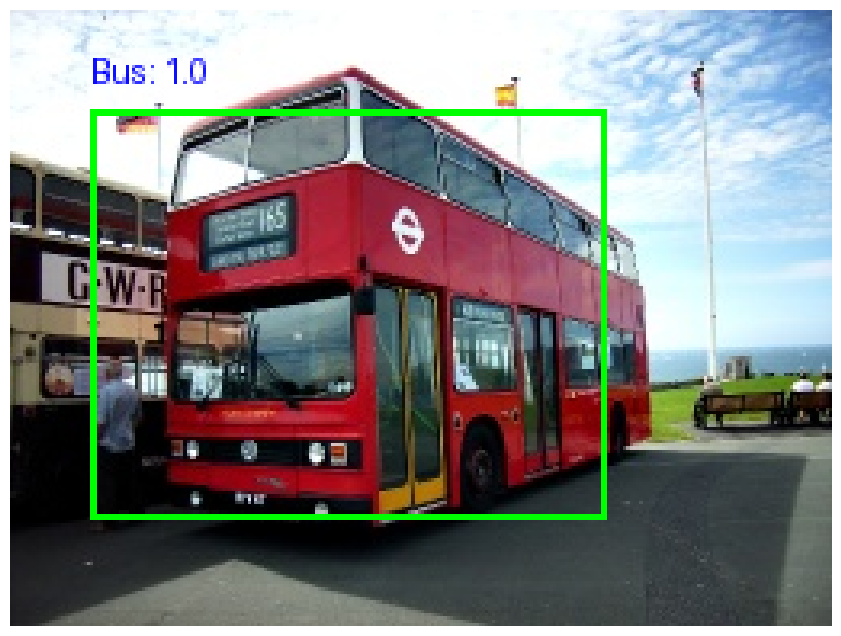

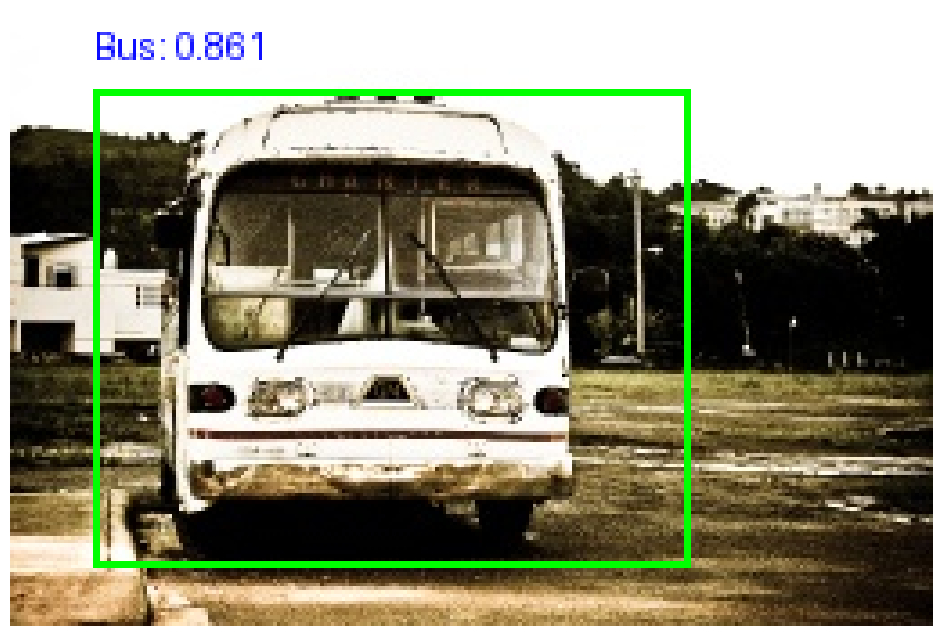

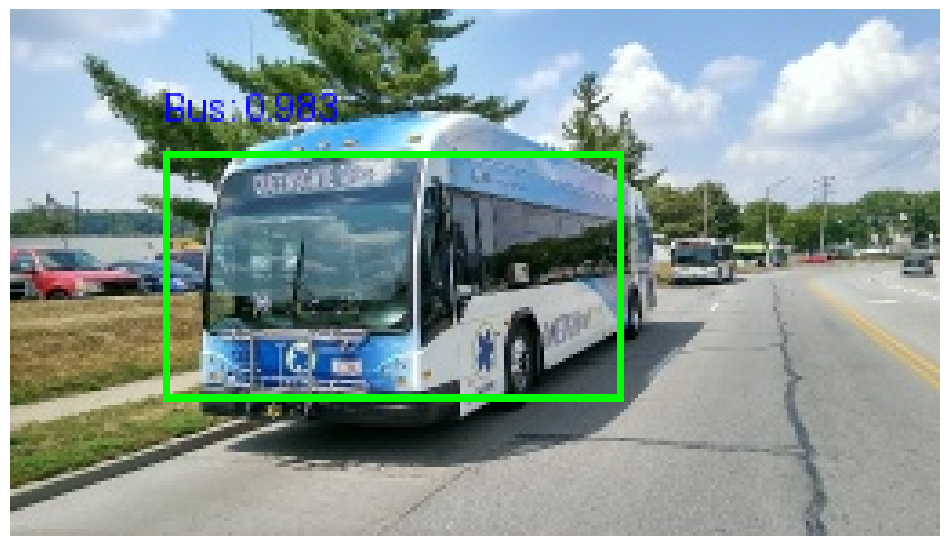

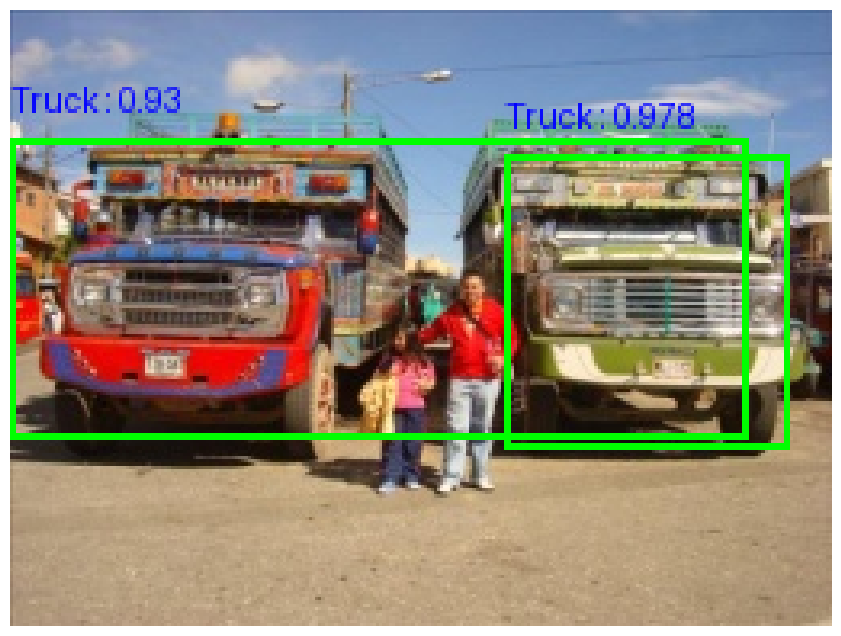

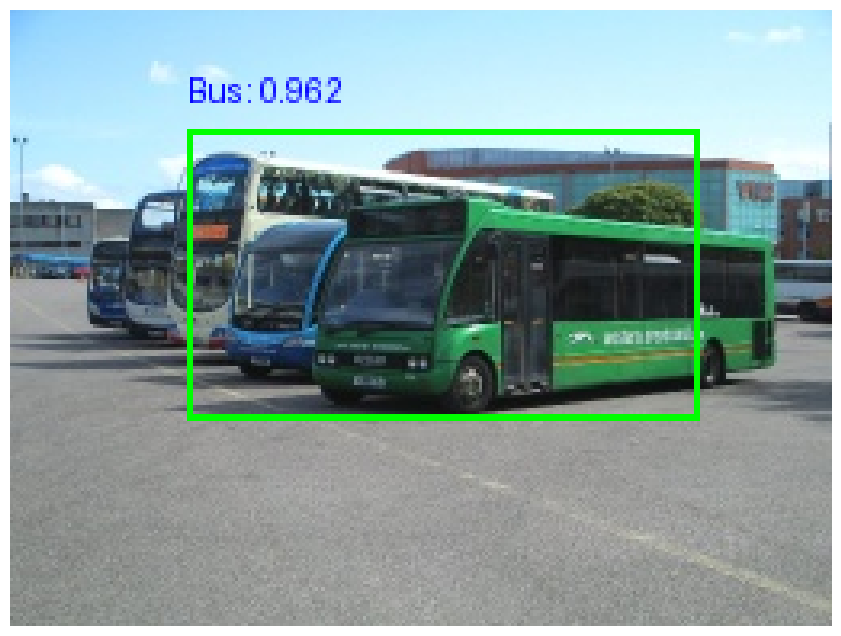

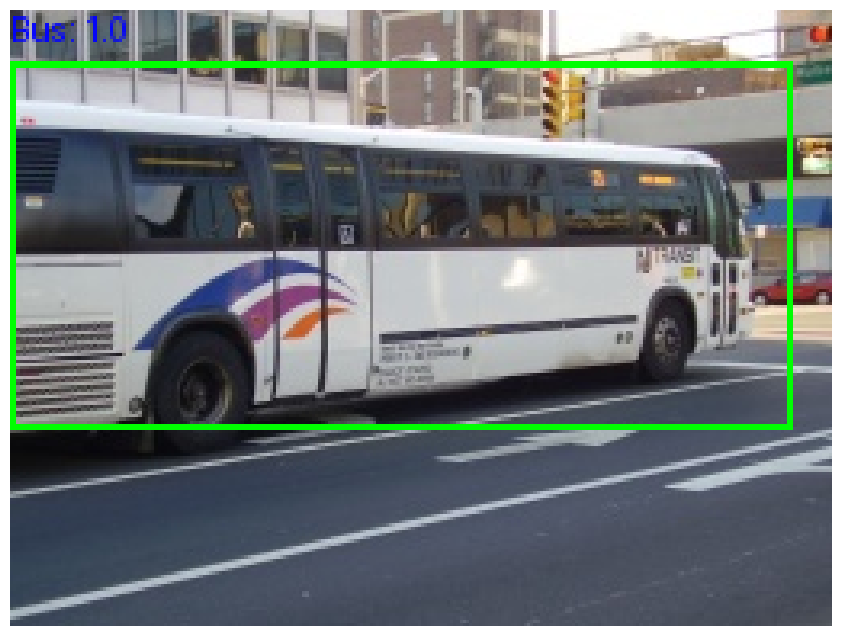

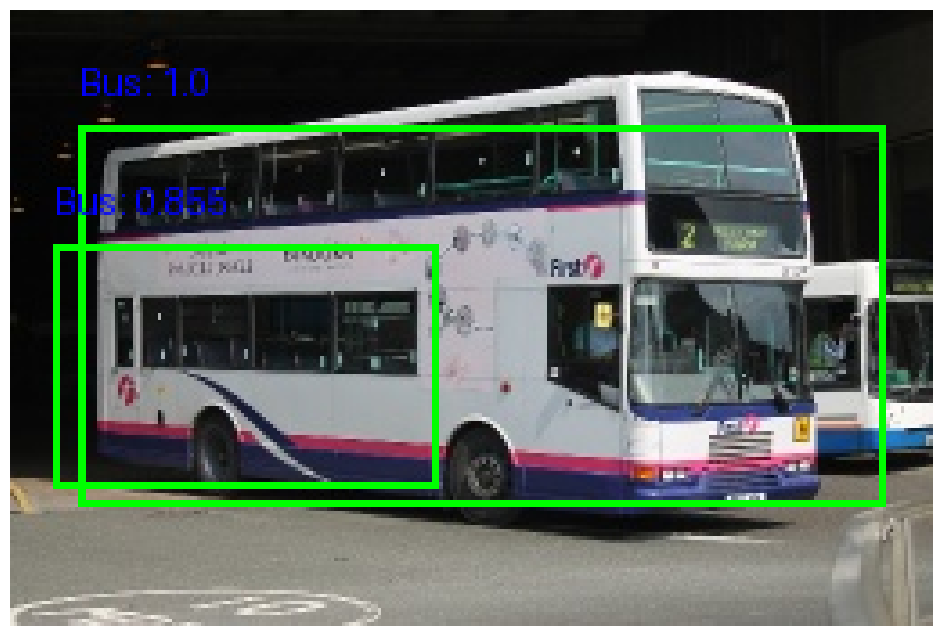

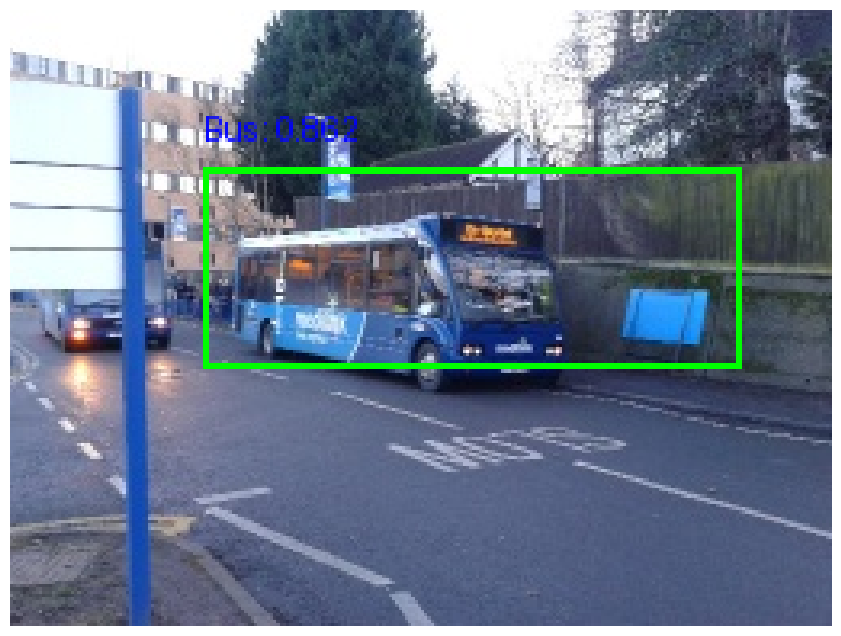

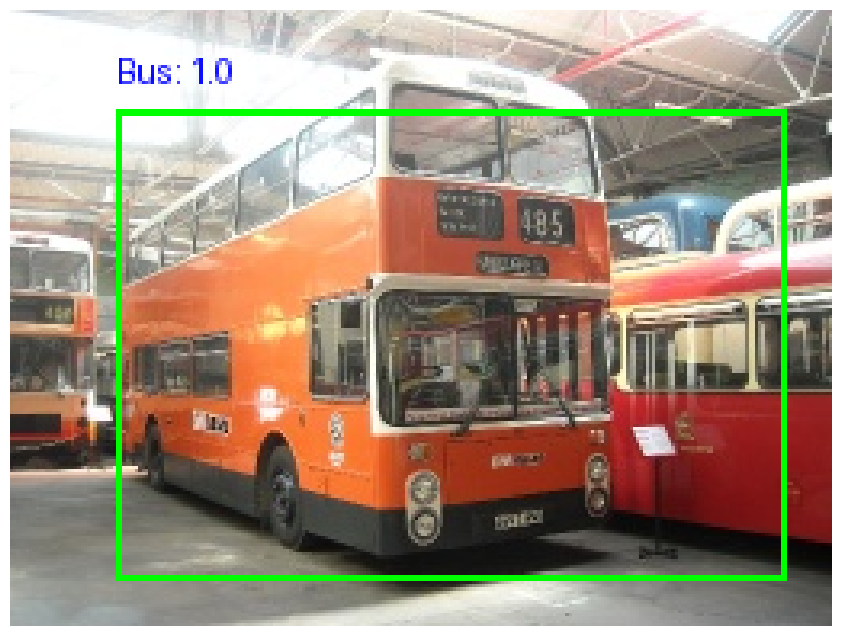

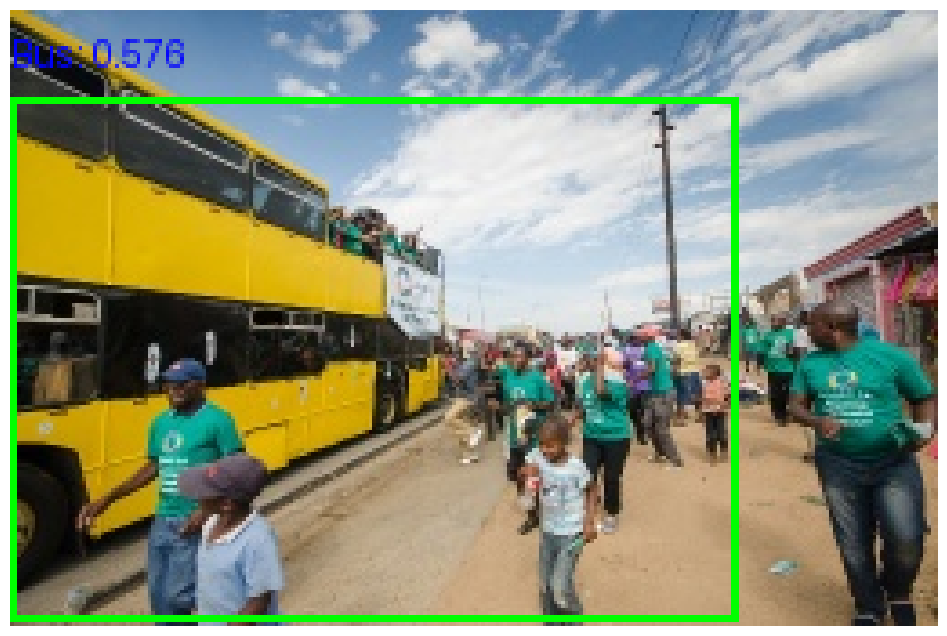

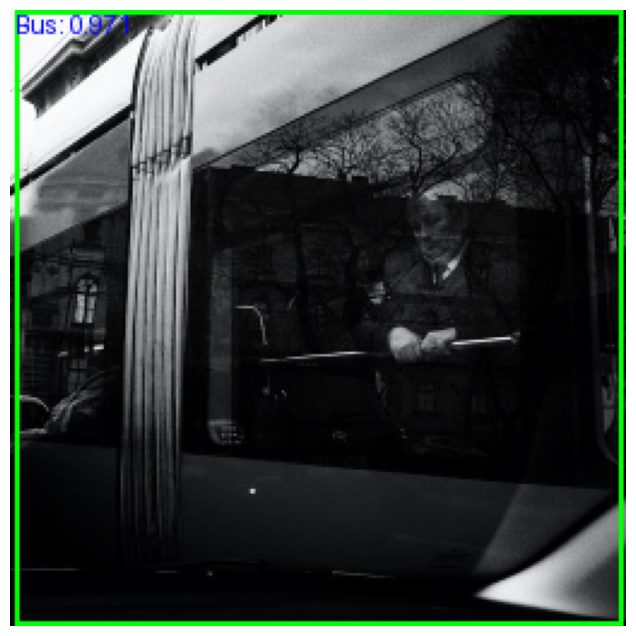

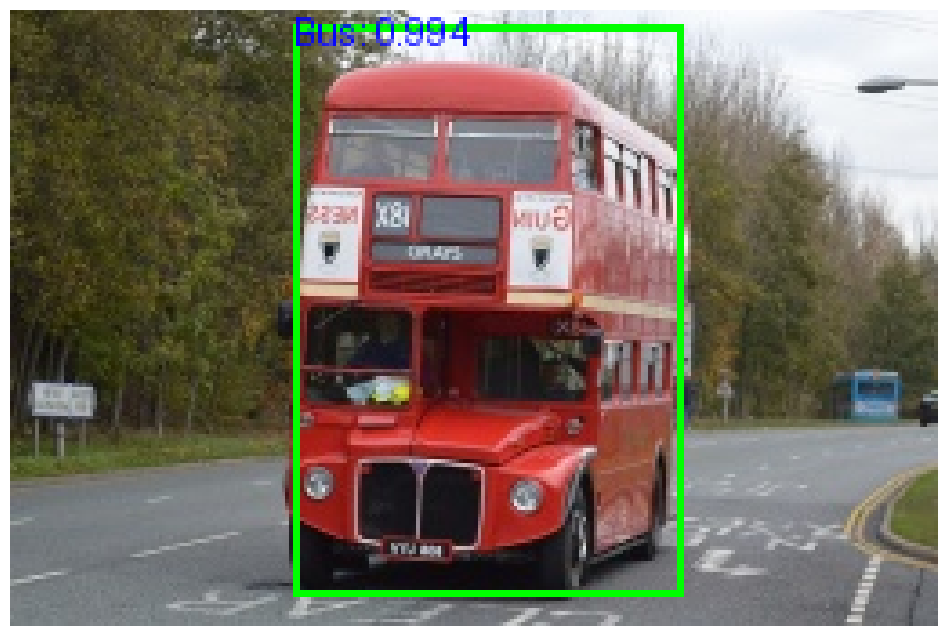

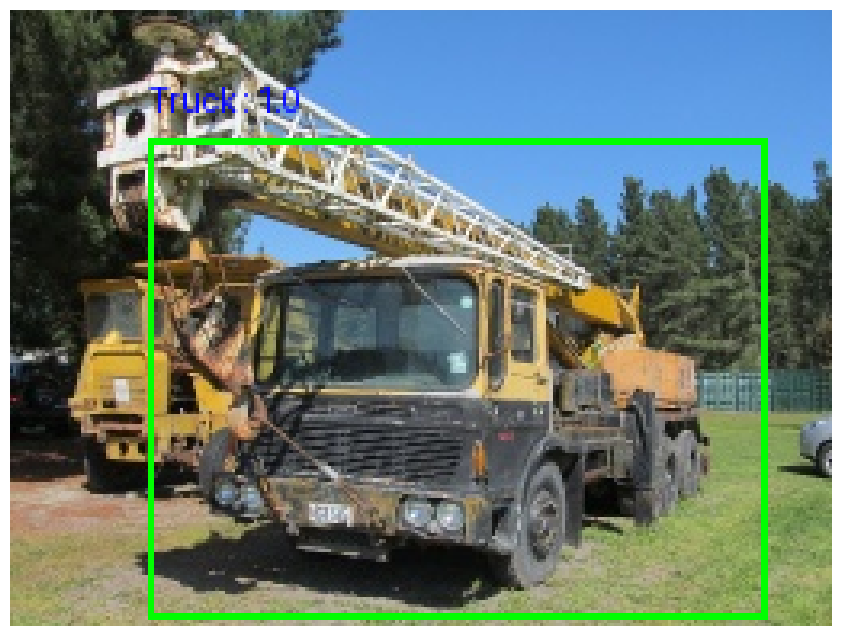

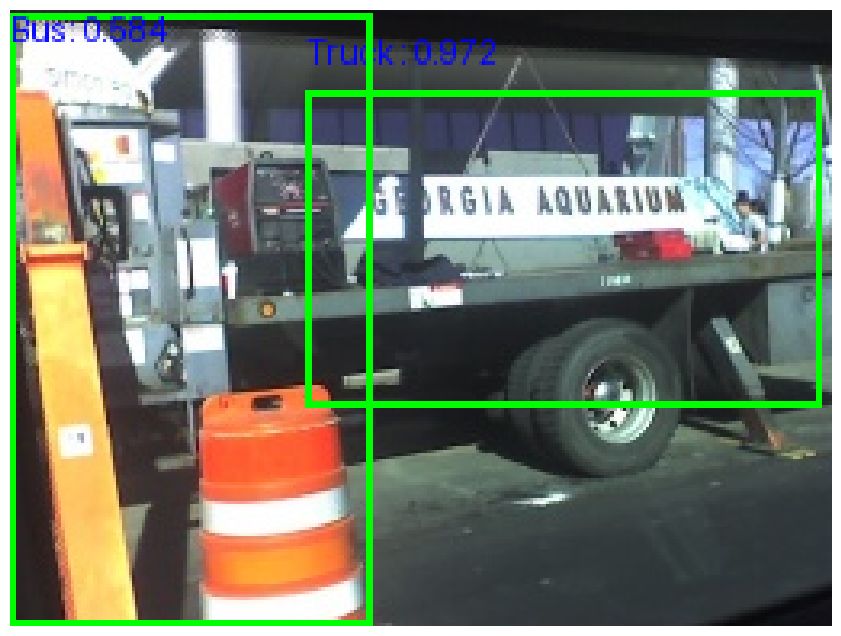

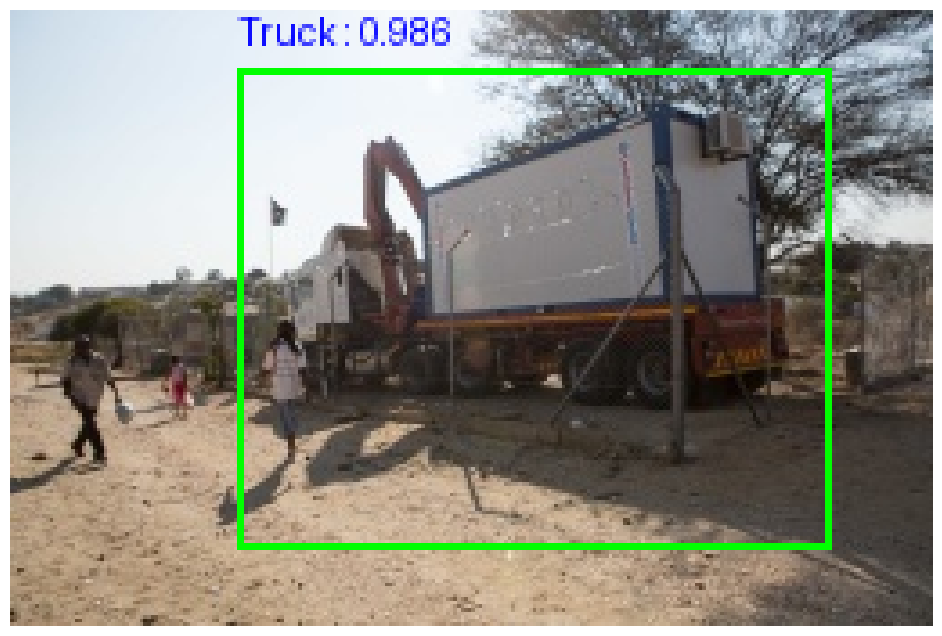

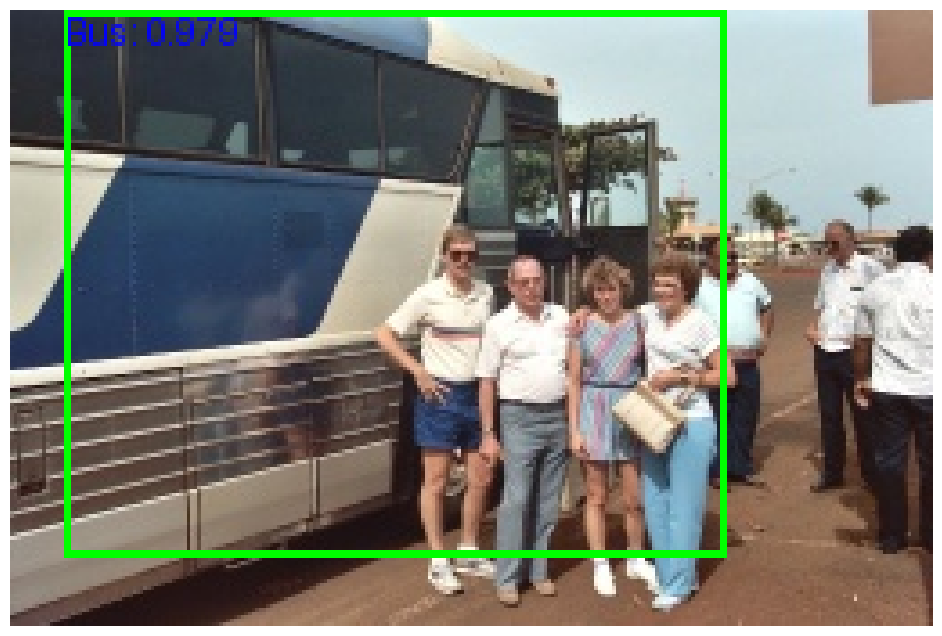

In [133]:
for i in range(0,len(test_set)):
    evaluate_on_unseen_image(test_set[i][3])